In [333]:
import pandas as pd
import numpy as np

In [334]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [335]:
print("Rows and Columns:")
df.shape

Rows and Columns:


(1200, 14)

In [336]:
print("********************* DATA INFORMATION ****************************")
print()
df.info()

********************* DATA INFORMATION ****************************

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 no

In [337]:
df.isnull().sum()


,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [338]:
df["CouponCode"] = df["CouponCode"].fillna(df["CouponCode"].mode()[0])
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [339]:
if df.duplicated().sum() == 0:
    print("No Duplicates in rows")
else:
    print("Duplicates Found in rows")



No Duplicates in rows


In [340]:
if df.columns.duplicated().sum() == 0:
    print("No Duplicates in columns")
else:
    print("Duplicates Found in columns")

No Duplicates in columns


In [341]:
print("********************* BASIC STATISTICS OF DATA ****************************")
print()
df.describe()

********************* BASIC STATISTICS OF DATA ****************************



,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


# **Data Visualization**

**Sales trend Over time**

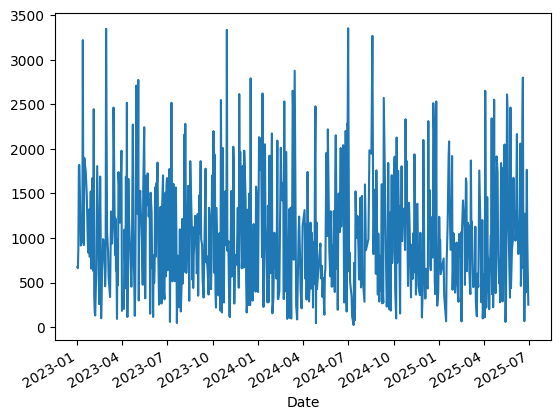

In [342]:
import matplotlib.pyplot as plt

df["Date"] = pd.to_datetime(df["Date"])
df.groupby("Date")["TotalPrice"].mean().plot()
plt.show()

**Extracting Useful features from date**

In [343]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayofWeek"] = df["Date"].dt.dayofweek
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,DayofWeek
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1,4,2
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8,23,4
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2,27,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10,15,6
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5,8,3


**Year Wise Sales**

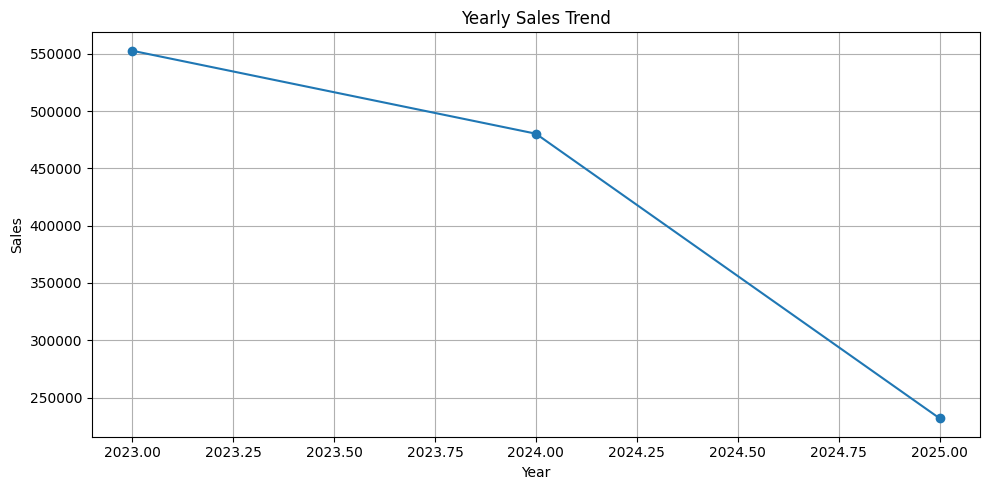

In [344]:
yearly_sales = df.groupby('Year')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
yearly_sales.plot(marker='o')
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

**Monthly Sales**

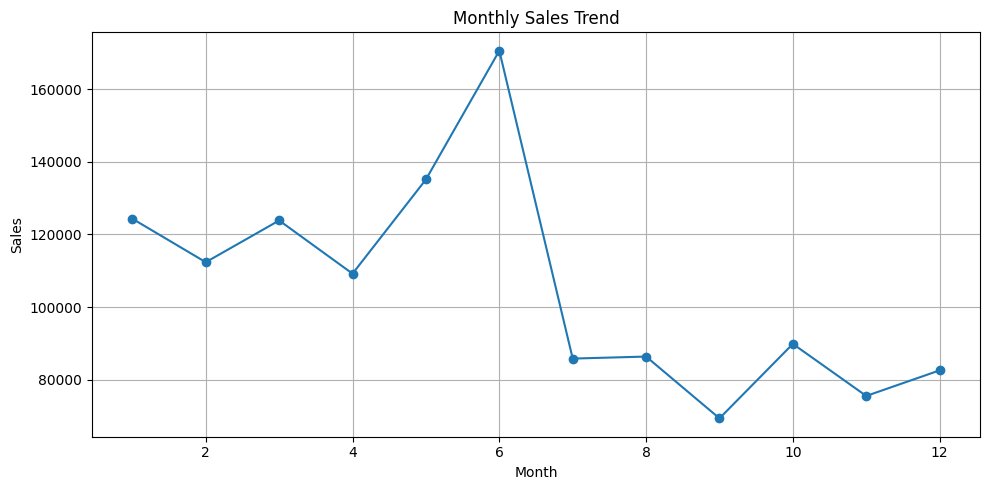

In [345]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

**Weekdays Wise Sales**

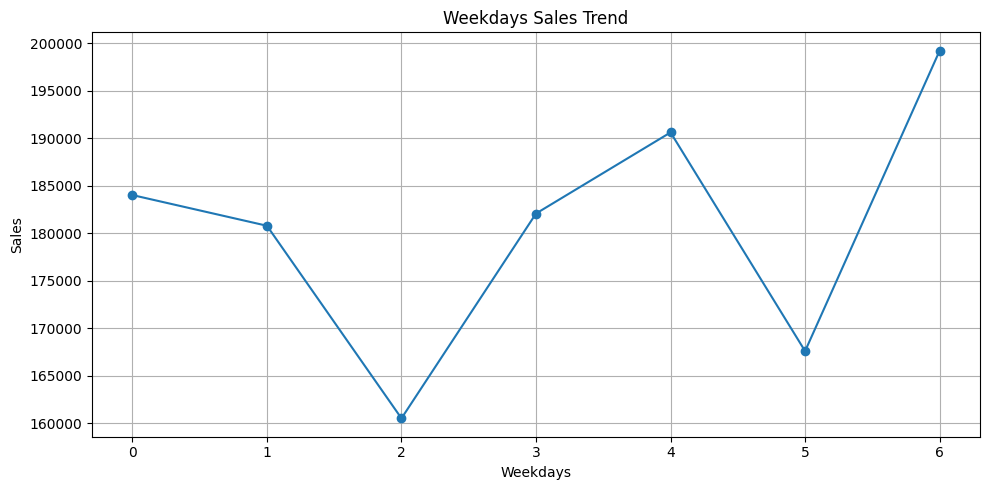

In [346]:
weekdays_sales = df.groupby('DayofWeek')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
weekdays_sales.plot(marker='o')
plt.title("Weekdays Sales Trend")
plt.xlabel("Weekdays")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

**Average Total Price by Payment Method**

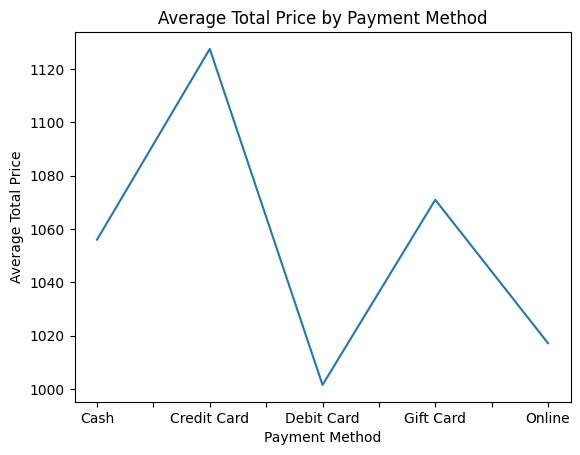

In [347]:
df.groupby("PaymentMethod")["TotalPrice"].mean().plot()
plt.xlabel("Payment Method")
plt.ylabel("Average Total Price")
plt.title("Average Total Price by Payment Method")
plt.show()

**Price By Quantity**

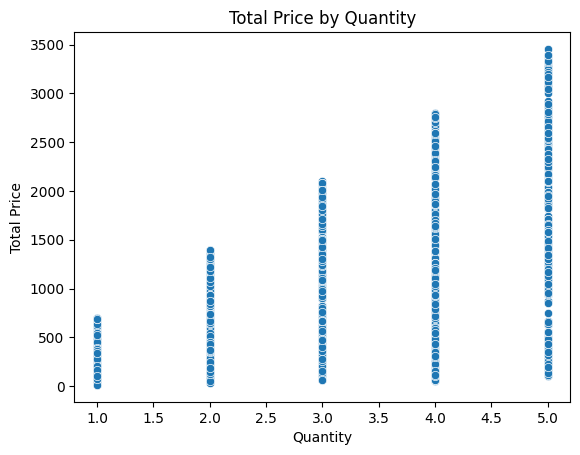

In [348]:
import seaborn as sns

sns.scatterplot(x="Quantity", y="TotalPrice", data=df)
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.title("Total Price by Quantity")
plt.show()

**Sales By Order Status (delivered, cancelled etc)**

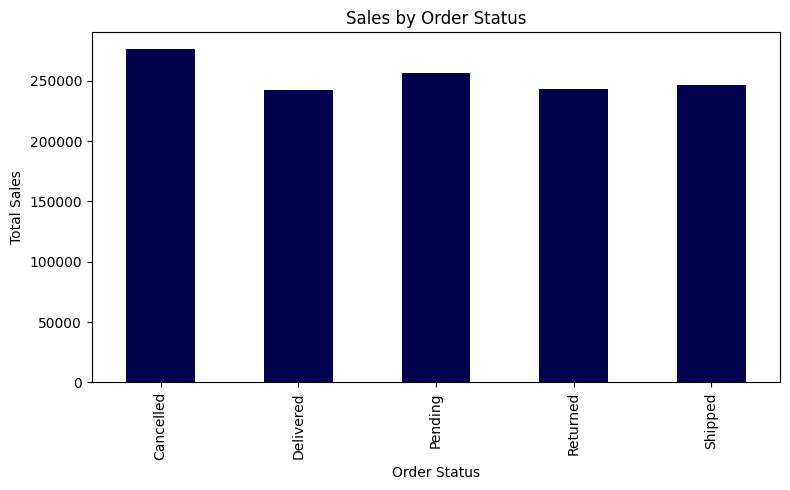

In [349]:
sales_by_status = df.groupby('OrderStatus')['TotalPrice'].sum()

plt.figure(figsize=(8,5))
sales_by_status.plot(kind='bar', cmap='seismic')
plt.title("Sales by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Total Sales")
plt.tight_layout()

**Product wise sales**

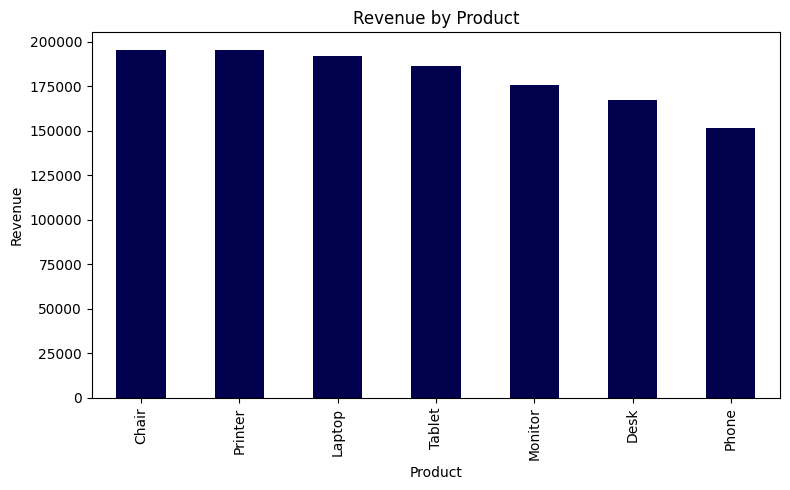

In [350]:
product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
product_sales.plot(kind='bar', cmap='seismic')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

**Distribution of order Status**

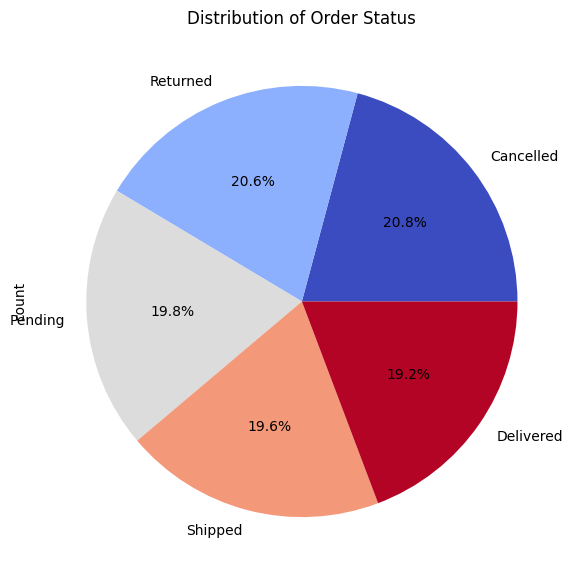

In [351]:
plt.figure(figsize=(7,7))
df["OrderStatus"].value_counts().plot(kind="pie", autopct="%1.1f%%", cmap="coolwarm")
plt.title("Distribution of Order Status")
plt.show()

**Sales/Revenue by referral Source (instagram, facebook etc)**

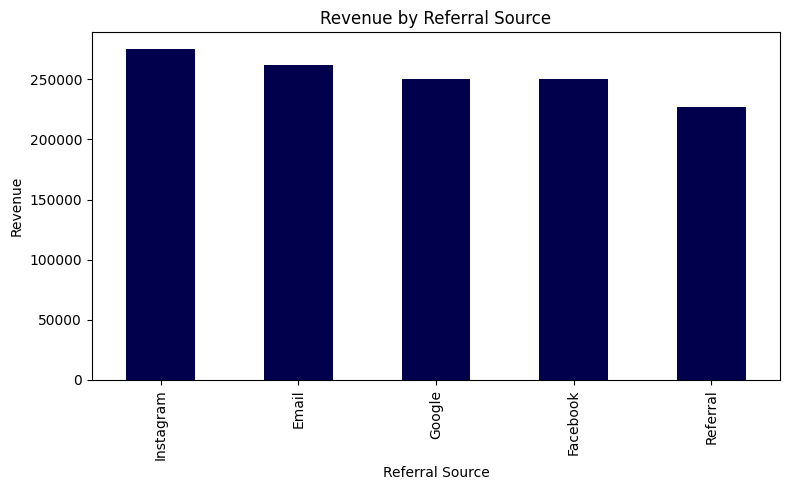

In [352]:
referral_sales = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
referral_sales.plot(kind='bar', cmap="seismic")
plt.title("Revenue by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

<Axes: >

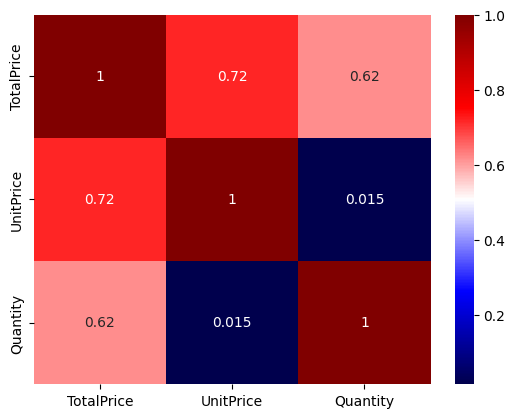

In [353]:
sns.heatmap(df[["TotalPrice", "UnitPrice", "Quantity"]].corr(), annot = True, cmap = "seismic")

*The data tells the story of a growing e-commerce business where sales varied over time, indicating changes in customer demand and purchasing behavior. Revenue was primarily driven by successful delivered orders, while cancelled and returned orders represented potential losses. Customers using certain payment methods tended to spend more on average, suggesting opportunities for targeted promotions. Additionally, higher purchase quantities generally contributed to increased revenue, highlighting the importance of encouraging larger orders. Overall, the analysis shows that sales performance is influenced by customer preferences, order fulfillment efficiency, and purchasing trends, providing valuable insights for improving business growth and profitability.*


----------------------------------------------------------------------
**Dropping unwanted columns**

In [354]:
columns_to_drop = ["OrderID", "CustomerID", "ShippingAddress", "TrackingNumber", "Date"]

df = df.drop(columns=columns_to_drop)
df.head()

,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,DayofWeek
0,Monitor,5,570.62,Debit Card,Shipped,7,SAVE10,Instagram,2853.10,2023,1,4,2
1,Phone,2,151.35,Online,Shipped,3,SAVE10,Referral,302.70,2024,8,23,4
2,Tablet,5,550.68,Credit Card,Cancelled,8,FREESHIP,Email,2753.40,2024,2,27,1
3,Chair,1,273.19,Debit Card,Returned,5,SAVE10,Facebook,273.19,2023,10,15,6
4,Printer,4,626.01,Online,Delivered,8,SAVE10,Email,2504.04,2025,5,8,3


# **Encoding Categorical Columns**

In [355]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = ["OrderStatus", "PaymentMethod", "ReferralSource", "Product", "CouponCode"]

for column in categorical_columns:
    df[column] = le.fit_transform(df[column])

df.head()


,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,DayofWeek
0,3,5,570.62,2,4,7,1,3,2853.10,2023,1,4,2
1,4,2,151.35,4,4,3,1,4,302.70,2024,8,23,4
2,6,5,550.68,1,0,8,0,0,2753.40,2024,2,27,1
3,0,1,273.19,2,3,5,1,1,273.19,2023,10,15,6
4,5,4,626.01,4,1,8,1,0,2504.04,2025,5,8,3


# **Splitting of Data**

In [356]:
from sklearn.model_selection import train_test_split

X = df.drop("TotalPrice", axis=1)
y = df["TotalPrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [357]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Model Training And Implementation**

In [358]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

**Function to calculate metrics**

In [359]:
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("Mean Squared Error:", mse)
    print("Root Mean Squared Error:", rmse)
    print("R2-Score:", r2)

***1. Linear Regression***

In [360]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

calculate_metrics(y_test, y_pred_lr)



Mean Squared Error: 83527.85285370801
Root Mean Squared Error: 289.01185590509607
R2-Score: 0.8902146814832361


***2. Random Forest Regressor***

In [361]:
RF = RandomForestRegressor(n_estimators=100, random_state=42)
RF.fit(X_train, y_train)
y_pred_RF = RF.predict(X_test)

calculate_metrics(y_test, y_pred_RF)

Mean Squared Error: 230.21013009487518
Root Mean Squared Error: 15.172677090575519
R2-Score: 0.9996974219784804


In [362]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

calculate_metrics(y_test, y_pred_dt)

Mean Squared Error: 822.8753874999998
Root Mean Squared Error: 28.68580463399972
R2-Score: 0.9989184489552903


In [366]:
print("Train Score for Linear Regression: ",lr.score(X_train, y_train))
print("Test Score for Linear Regression: ",lr.score(X_test, y_test))
print()

print("Train Score for Random Forest Regressor: ",RF.score(X_train, y_train))
print("Test Score for Random Forest Regressor: ",RF.score(X_test, y_test))
print()

print("Train Score for Decision Tree Regressor: ",dt.score(X_train, y_train))
print("Test Score for Decision Tree Regressor: ",dt.score(X_test, y_test))
print()

Train Score for Linear Regression:  0.8779783881196326
Test Score for Linear Regression:  0.8902146814832361

Train Score for Random Forest Regressor:  0.9999503342648023
Test Score for Random Forest Regressor:  0.9996974219784804

Train Score for Decision Tree Regressor:  1.0
Test Score for Decision Tree Regressor:  0.9989184489552903

